# Welcome to Modal notebooks!

Write Python code and collaborate in real time. Your code runs in Modal's
**serverless cloud**, and anyone in the same workspace can join.

This notebook comes with some common Python libraries installed. Run
cells with `Shift+Enter`.

In [17]:
%uv pip install torch transformers datasets Pillow umap-learn
%uv pip install s3fs tiffile imagecodecs zarr scikit-image
%uv pip install matplotlib seaborn
%uv pip install -U numba umap-learn

Using Python 3.12.6 environment at: /usr/local
Resolved 72 packages in 126ms
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
Prepared 1 package in 42ms
Uninstalled 1 package in 3ms
Installed 1 package in 131ms
 - fsspec==2026.1.0
 + fsspec==2025.10.0
Note: you may need to restart the kernel to use updated packages.
Using Python 3.12.6 environment at: /usr/local
Resolved 36 packages in 70ms
Uninstalled 1 package in 2ms
Installed 1 package in 153ms
 - fsspec==2025.10.0
 + fsspec==2026.1.0
Note: you may need to restart the kernel to use updated packages.
Using Python 3.12.6 environment at: /usr/local
Audited 2 packages in 9

In [18]:
try:
    from umap.umap_ import UMAP
except ImportError:
    from umap import UMAP

In [19]:
# Set device
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [20]:
from datasets import load_dataset

ds_train = load_dataset("dakomura/tcga-ut", "internal", split="train", streaming=True) # if you get an error here, try setting streaming=False. This will download the dataset locally in advance.
ds_train = ds_train.filter(lambda sample: "Lung" in sample["json"]["label"])

ds_test = load_dataset("dakomura/tcga-ut", "internal", split="test", streaming=True)
ds_test = ds_test.filter(lambda sample: "Lung" in sample["json"]["label"])

Resolving data files:   0%|          | 0/39 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/39 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/39 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/39 [00:00<?, ?it/s]

In [21]:
from transformers import AutoImageProcessor, AutoModel

# Load phikon-v2
processor = AutoImageProcessor.from_pretrained("owkin/phikon-v2", use_fast=True)
model = AutoModel.from_pretrained("owkin/phikon-v2")
model.eval()
model.to(device)

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Dinov2Model(
  (embeddings): Dinov2Embeddings(
    (patch_embeddings): Dinov2PatchEmbeddings(
      (projection): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): Dinov2Encoder(
    (layer): ModuleList(
      (0-23): 24 x Dinov2Layer(
        (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (attention): Dinov2Attention(
          (attention): Dinov2SelfAttention(
            (query): Linear(in_features=1024, out_features=1024, bias=True)
            (key): Linear(in_features=1024, out_features=1024, bias=True)
            (value): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (output): Dinov2SelfOutput(
            (dense): Linear(in_features=1024, out_features=1024, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (layer_scale1): Dinov2LayerScale()
        (drop_path): Identity()
        (norm2): LayerNorm((1024,),

In [22]:
def load_and_process_image(sample):
    image_bytes = sample["jpg"]
    # image = Image.open(io.BytesIO(image_bytes))
    image = image_bytes
    return {
        "image": image,
        "label": sample["json"]["label"],
        "patient_id": sample["__key__"][:12] # TCGA-XX-XXXX
    }

ds_train_processed = ds_train.map(load_and_process_image, remove_columns=["jpg", "json", "__key__", "__url__"])
ds_test_processed = ds_test.map(load_and_process_image, remove_columns=["jpg", "json", "__key__", "__url__"])

Sample 1
Label: Lung_adenocarcinoma
Patient ID: TCGA-55-8614


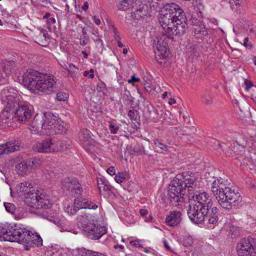

Sample 2
Label: Lung_adenocarcinoma
Patient ID: TCGA-55-8614


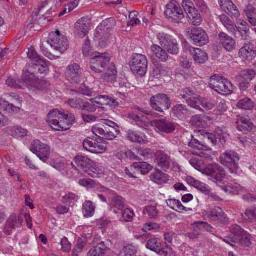

Sample 3
Label: Lung_adenocarcinoma
Patient ID: TCGA-71-8520


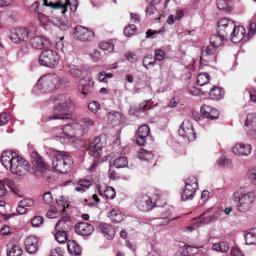

Sample 4
Label: Lung_adenocarcinoma
Patient ID: TCGA-86-7955


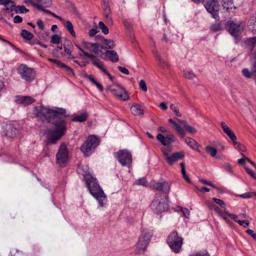

Sample 5
Label: Lung_adenocarcinoma
Patient ID: TCGA-55-7903


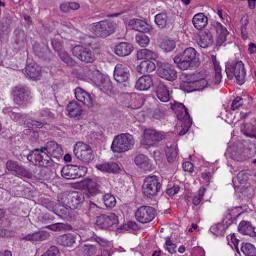

In [23]:
iter_ds = iter(ds_train_processed)

### YOUR CODE to visualize images here ###
# Hint: iterate over the data loader
# use display from IPython.display to show images in a Jupyter notebook
from IPython.display import display

# Visualize first N samples
N = 5

for i in range(N):
    sample = next(iter_ds)

    img = sample["image"]
    label = sample["label"]
    patient_id = sample["patient_id"]

    print(f"Sample {i+1}")
    print(f"Label: {label}")
    print(f"Patient ID: {patient_id}")

    display(img)
    print("=" * 50)

### Are histopathology images different from common images, e.g., as seen in the ImageNet-1k dataset?
If so, what implications would this have…

 * to data distributions?
 * to general pre-trained FMs for RGB images?
 * to data pre-processing?

---

Common images are photos of objects such as dogs, cats, cars, wih clear shapes and edges. In histopathology images, the important features are the texture, the level of stain, relative sizes of nuclei and cells. One image contains many cells, and these cells combine into the correct evaluation.

Implications
1. Data distribution:
    * Instead in RGB, H&E data only has red and blue
    * Histology images have no clear up/down side, whereas animal photo's do.
2. General pre-trained foundation models:
    * General models trained on natural photographs, would still be able to identify shapes, edges, color differences, but later on will fail, as histopathology images do not agree with their training: there are no dog faces, sky, eyes etc. in the images.
3. Data pre-processing:
    * To see the details in texture, higher resolution images are needed. On the contrary, cat/dog images can be very compressed and still be correctly identified.
    * Between differnt samples in the dataset, the staining levels and magnification have to be normalized.

In [25]:
ds_train_processed = ds_train_processed.with_format("torch")
ds_test_processed = ds_test_processed.with_format("torch")

BATCH_SIZE = 32
EMBEDDING_SIZE = 1024
NR_BATCHES = 100

dl_train = torch.utils.data.DataLoader(
    ds_train_processed,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=8,
)

In [26]:
from tqdm import tqdm

embeddings = torch.zeros((BATCH_SIZE * NR_BATCHES, EMBEDDING_SIZE))
labels = []
patient_ids = []

with torch.inference_mode():
    with torch.autocast(device.type, torch.bfloat16):
        for i, batch in enumerate(tqdm(dl_train, total=NR_BATCHES)):
            inputs = processor(batch["image"], return_tensors="pt").to(device)

            outputs = model(**inputs)
            last_hidden = outputs.last_hidden_state
            emb = last_hidden.mean(dim=1)

            start = i * BATCH_SIZE
            end = start + emb.shape[0]

            embeddings[start:end] = emb.cpu()

            labels.extend(batch["label"])
            patient_ids.extend(batch["patient_id"])

            if i == (NR_BATCHES - 1):
                break

 99%|████████████████████████████████████████████████████████████████████████▎| 99/100 [04:10<00:02,  2.53s/it]


/usr/local/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


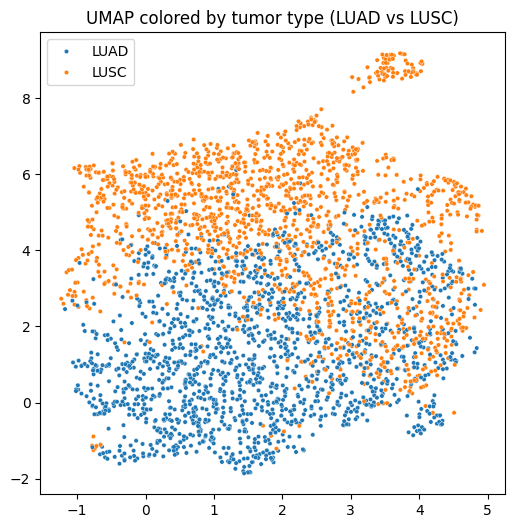

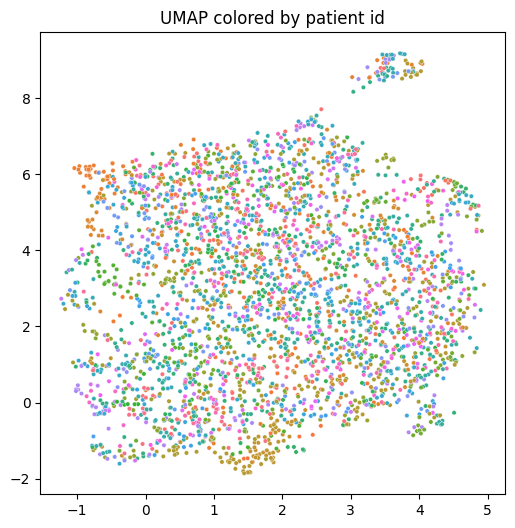

In [27]:
# Apply UMAP
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from umap import UMAP

labels = np.array(labels)
patient_ids = np.array(patient_ids)

X = embeddings.numpy()

tumor_labels = np.array(
    ["LUAD" if "adenocarcinoma" in l.lower() else "LUSC" for l in labels]
)

umap = UMAP(n_neighbors=30, min_dist=0.3, n_components=2, random_state=42)
X_umap = umap.fit_transform(X)

plt.figure(figsize=(6,6))
sns.scatterplot(
    x=X_umap[:,0],
    y=X_umap[:,1],
    hue=tumor_labels,
    s=10
)
plt.title("UMAP colored by tumor type (LUAD vs LUSC)")
plt.show()

plt.figure(figsize=(6,6))
sns.scatterplot(
    x=X_umap[:,0],
    y=X_umap[:,1],
    hue=patient_ids,
    legend=False,
    s=10
)
plt.title("UMAP colored by patient id")
plt.show()

### What do you see in the UMAPs?
Are there overlapping classes?  
If so why, if not why not?  
How nicely are the cancer types clustering?  

---

LUSC mostly in the upper part of the UMAP.  
LUAD mostly in the lower part of the UMAP.  
In the middle right, there's a section where both classes overlap.  

The dataset contains slides with patient tissue. Each slide is classified to contain LUSC or LUAD, but one slide contains many cells. There may be some LUAD celss in a predominantly LUAD slide, and vice versa. Also Each slide may contain a portion of healthy cells. These effect could all contribute to the overlap we observe.

Including examples of healthy lung tissue may improve classification. Perhaps, the right overlapping section are rapresentations of the healthy cells in the slides of both classes.



/usr/local/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


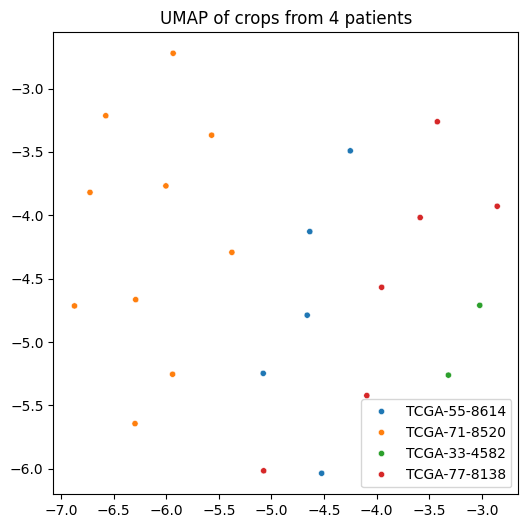

In [ ]:
selected_patients = [
    "TCGA-33-4582",
    "TCGA-55-8614",
    "TCGA-77-8138",
    "TCGA-71-8520"
]

mask = np.isin(patient_ids, selected_patients)

X_sub = X[mask]
patients_sub = patient_ids[mask]

umap_sub = UMAP(n_neighbors=30, min_dist=0.3, n_components=2, random_state=42)
X_sub_umap = umap_sub.fit_transform(X_sub)

plt.figure(figsize=(6,6))
sns.scatterplot(x=X_sub_umap[:,0], y=X_sub_umap[:,1], hue=patients_sub, s=20)
plt.title("UMAP of crops from 4 patients")
plt.show()


### Do we also see clustering in the patients? Why could this be?

There are specific regioins per patient in the UMAP plot, so samples within a patient have similar embeddings.

Each patient has their own genetic makeup, behaviour and environment, which could lead to some specific cell morphology. Patients may have samples taken at different stages into the disease. Samples may have been submitted by different laboratories. Then you would also have the effect of different technicians, staining conditions, and microscopy type and settings. These batch effects also make images from the same patient look more similar to each other.

The model learns not only features related to the disease, but also patient-specific and acquisition-specific characteristics. As a result, image tiles from the same patient tend to group together in the UMAP plot.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Convert labels to binary (1 = LUAD, 0 = LUSC)
y_train = np.array([1 if "adenocarcinoma" in l.lower() else 0 for l in labels])

X_train = embeddings.numpy()

# Sanity check
print("Train label distribution:", np.unique(y_train, return_counts=True))

# Train logistic regression
clf = LogisticRegression(max_iter=2000)
clf.fit(X_train, y_train)

Train label distribution: (array([0, 1]), array([1563, 1637]))


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
dl_test = torch.utils.data.DataLoader(
    ds_test_processed,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=8,
)

In [ ]:
import torch
import numpy as np
from tqdm import tqdm

test_embeddings = []
test_labels = []
test_patient_ids = []

with torch.inference_mode():
    with torch.autocast(device.type, torch.bfloat16):
        for i, batch in enumerate(tqdm(dl_test, total=NR_BATCHES)):
            inputs = processor(batch["image"], return_tensors="pt").to(device)

            outputs = model(**inputs)
            emb = outputs.last_hidden_state.mean(dim=1)

            test_embeddings.append(emb.cpu())
            test_labels.extend(batch["label"])
            test_patient_ids.extend(batch["patient_id"])

            if i == NR_BATCHES - 1:
                break

X_test = torch.cat(test_embeddings).numpy()
y_test = np.array([1 if "adenocarcinoma" in l.lower() else 0 for l in test_labels])

test_patient_ids = np.array(test_patient_ids)

print("Test label distribution:", np.unique(y_test, return_counts=True))

 99%|████████████████████████████████████████████████████████████████████████▎| 99/100 [03:55<00:02,  2.38s/it]

Test label distribution: (array([0, 1]), array([1596, 1604]))


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", acc)
print("F1-score:", f1)
print("Confusion matrix:\n", cm)


Accuracy: 0.88625
F1-score: 0.8900302114803625
Confusion matrix:
 [[1363  233]
 [ 131 1473]]


Both classes are well recognized


|           | Pred LUSC | Pred LUAD |
|-----------|:---------:|:---------:|
| True LUSC |      1363 |       233 |
| True LUAD |       131 |      1473 |

More often, Lung squamous cell carcinoma (LUSC) is falsely identified as Lung adenocarcinoma (LUAD) (233 times), than the other way around (131 times).

In [ ]:
import pandas as pd

patient_ids_test = test_patient_ids
labels_test = test_labels
lr_predictions = clf.predict(X_test)

df = pd.DataFrame({"pid": patient_ids_test, "prediction": lr_predictions, "label": labels_test})
df_majority_voting = df.groupby("pid").agg({"prediction":pd.Series.mode, "label":"first"})

predictions_tissue = df_majority_voting["prediction"].values
labels_tissue = df_majority_voting["label"].values

# resolve ties
predictions_tissue = [p[0] if isinstance(p, np.ndarray) else p for p in predictions_tissue]

Now calculate tissue-level accuracies and f1-score.
Would you expect improving performances? Why?

---


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

y_tissue = np.array([1 if "adenocarcinoma" in l.lower() else 0 for l in labels_tissue])

predictions_tissue = np.array(predictions_tissue)

acc_tissue = accuracy_score(y_tissue, predictions_tissue)
f1_tissue = f1_score(y_tissue, predictions_tissue)

print("Tissue-level Accuracy:", acc_tissue)
print("Tissue-level F1:", f1_tissue)

Tissue-level Accuracy: 0.9090909090909091
Tissue-level F1: 0.9104477611940298


If we move up from a section of a tissue (one slide), to the whole tissue level, then I expect the performance to improve, because we have a larger dataset, composed of the tissue of one patient. Thus there is less (systematic) noise, while the cells specific to the tumour in one patient are more easily recognised.

In [ ]:
import s3fs
import os

fs = s3fs.S3FileSystem(anon=True)
s3_path = 'lin-2023-orion-crc/data/CRC10/18459_LSP10452_US_SCAN_OR_001__091355-registered.ome.tif'

# Local filename to save the image
local_filename = 'crc10_he_wsi.ome.tif'

if not os.path.exists(local_filename):
    # Download the file from S3 to local filesystem
    fs.get(s3_path, local_filename)

print(f'Downloaded {local_filename}')

Downloaded crc10_he_wsi.ome.tif


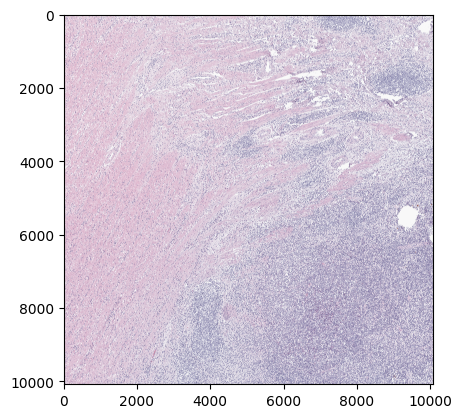

In [ ]:
import tifffile

region = tifffile.imread(local_filename)
region = region[15000:25080, 5000:15080]
plt.imshow(region)

In [ ]:
embeddings_cls = torch.zeros((45,45, EMBEDDING_SIZE))
embeddings_ps = torch.zeros((630,630, EMBEDDING_SIZE))

region_x, region_y = region.shape[:2]

with torch.inference_mode():
    with torch.autocast(device.type, torch.bfloat16):
        H, W = region.shape[:2]
        crop_size = 224
        stride = 224  # no overlap
        
        # Number of crops per dimension (should be 45 for 10080 / 224)
        nx = H // crop_size
        ny = W // crop_size
        
        print(nx, ny)
        
        for x in range(nx):
            for y in range(ny):
                crop = region[
                    x*crop_size:(x+1)*crop_size,
                    y*crop_size:(y+1)*crop_size
                ]
        
                inputs = processor(crop, return_tensors="pt").to(device)
                outputs = model(**inputs)
        
                # CLS token
                cls_tokens = outputs.last_hidden_state[:, 0, :].cpu()  # (1, D)
                embeddings_cls[x, y] = cls_tokens[0]
        
                # Patch tokens (remove CLS)
                patch_tokens = outputs.last_hidden_state[:, 1:, :].cpu()  # (1, 196, D)
                patch_tokens = patch_tokens.reshape(14, 14, EMBEDDING_SIZE)
        
                embeddings_ps[
                    x*14:(x+1)*14,
                    y*14:(y+1)*14
                ] = patch_tokens
        pass

45 45


In [ ]:
import torch
import torch.nn.functional as F

# Example Top left token
# For the cls tokens first
cls_00 = embeddings_cls[0, 0]  # shape: (EMBEDDING_SIZE,)
cls_00 = cls_00.unsqueeze(0)  # shape: (1, EMBEDDING_SIZE)

vectors_all_cls = embeddings_cls.view(-1, embeddings_cls.shape[2])
cosine_sim_cls_00 = F.cosine_similarity(cls_00, vectors_all_cls, dim=1)
cosine_sim_cls_00 = cosine_sim_cls_00.reshape(embeddings_cls.shape[:2])

# For the ps tokens 
ps_00 = embeddings_ps[0, 0]  # shape: (EMBEDDING_SIZE,)
ps_00 = torch.mean(embeddings_ps[:14, :14], dim=(0,1))
ps_00 = ps_00.unsqueeze(0)  # shape: (1, EMBEDDING_SIZE)

vectors_all_ps = embeddings_ps.view(-1, embeddings_ps.shape[2])
cosine_sim_ps_00 = F.cosine_similarity(ps_00, vectors_all_ps, dim=1)
cosine_sim_ps_00 = cosine_sim_ps_00.reshape(embeddings_ps.shape[:2])

In [ ]:
# Bottom-right CLS prototype
cls_nn = embeddings_cls[-1, -1].unsqueeze(0)

cosine_sim_cls_nn = F.cosine_similarity(cls_nn, vectors_all_cls, dim=1)
cosine_sim_cls_nn = cosine_sim_cls_nn.reshape(embeddings_cls.shape[:2])

# Bottom-right patch prototype (mean of last 14x14)
ps_nn = torch.mean(embeddings_ps[-14:, -14:], dim=(0,1)).unsqueeze(0)

cosine_sim_ps_nn = F.cosine_similarity(ps_nn, vectors_all_ps, dim=1)
cosine_sim_ps_nn = cosine_sim_ps_nn.reshape(embeddings_ps.shape[:2])


/tmp/ipykernel_206/744595007.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  cosine_sim_cls_00_resized = resize(np.array(cosine_sim_cls_00), (region_x, region_y))
/tmp/ipykernel_206/744595007.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  cosine_sim_cls_nn_resized = resize(np.array(cosine_sim_cls_nn), (region_x, region_y))
/tmp/ipykernel_206/744595007.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __a

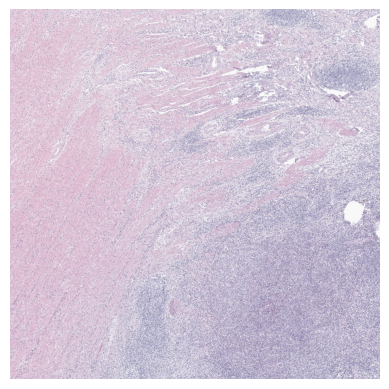

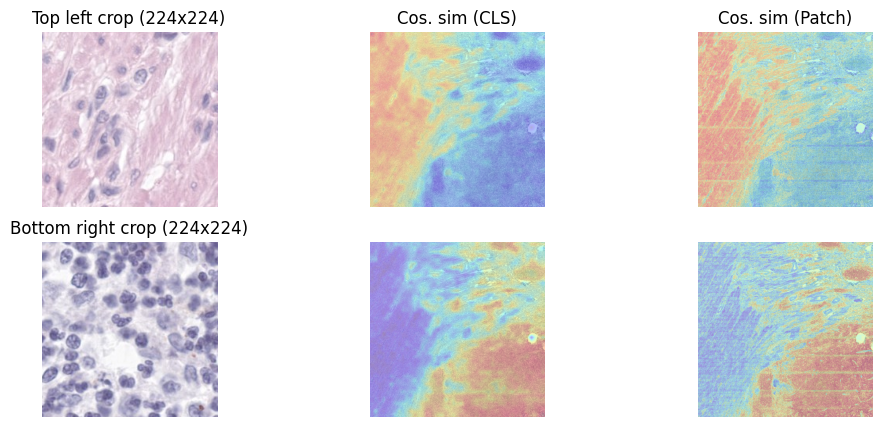

In [ ]:
from skimage.transform import resize



cosine_sim_cls_00_resized = resize(np.array(cosine_sim_cls_00), (region_x, region_y))
cosine_sim_cls_nn_resized = resize(np.array(cosine_sim_cls_nn), (region_x, region_y))

cosine_sim_ps_00_resized = resize(np.array(cosine_sim_ps_00), (region_x, region_y))
cosine_sim_ps_nn_resized = resize(np.array(cosine_sim_ps_nn), (region_x, region_y))


plt.imshow(region[::10, ::10])
plt.axis('off')
plt.show()

fig, axs = plt.subplots(2,3, figsize=(12, 5))
axs = axs.flatten()
axs[0].imshow(region[:224, :224])
axs[0].set_title("Top left crop (224x224)")
axs[1].imshow(region[::10, ::10])
axs[1].imshow(cosine_sim_cls_00_resized[::10, ::10], alpha=0.3, cmap="jet")
axs[2].imshow(region[::10, ::10])
axs[2].imshow(cosine_sim_ps_00_resized[::10, ::10], alpha=0.3, cmap="jet")
axs[3].imshow(region[-224:, -224:])
axs[3].set_title("Bottom right crop (224x224)")
axs[4].imshow(region[::10, ::10])
axs[4].imshow(cosine_sim_cls_nn_resized[::10, ::10], alpha=0.3, cmap="jet")
axs[5].imshow(region[::10, ::10])
axs[5].imshow(cosine_sim_ps_nn_resized[::10, ::10], alpha=0.3, cmap="jet")

axs[1].set_title("Cos. sim (CLS)")
axs[2].set_title("Cos. sim (Patch)")

for ax in axs:
    ax.axis('off')

Visualize the cosine similarities on top of the image between the selected prototypes and all other embeddings (once for the cls tokens, once for the patch tokens).
* What do you observe?
* What could this be useful for in a clinical setting?
---
1. The heatmaps show regions within the whole slide with similar appearance to the Top left crop (upper row) or the Bottom righ crop (lower row). High similarity to the prototype is indicated with red to yellow colour (cosine of angle between vectors of prototype and the respective embedding is among the higher values in the resuls), low similarity with cyan to blue colour.
2. You can quickly find tissues similar to the prototype. You only need to identify a particular tumour once, and the AI model indicates where in the tissue similar tumours are located. You can also clearly see the outline between the tumour and (presumably) healthy tissue.
